# SVM Baseline — Drug-Drug Interaction Prediction
This notebook trains a Support Vector Machine classifier to predict the **dominant reaction category** of a drug-drug interaction from ChemBERTa molecular embeddings.

It serves as a **baseline model** to benchmark against the GNN.

**Note on approach:** Rather than treating each (drug pair × reaction category) row as a separate sample — which causes the same drug pair to appear with identical features but different labels — we pivot the data so each drug pair has **one row** with 12 PRR scores as features (one per reaction category). The label is the dominant reaction category (highest PRR). This gives SVM a meaningful, non-contradictory learning signal.

**Pipeline:**
1. Load `data/twosides_edge_labels.csv`
2. Pivot to one row per drug pair with 12 PRR features
3. Load ChemBERTa embeddings
4. Build drug pair feature vectors
5. Train/test split
6. Train and evaluate SVM
7. Per-class report and confusion matrix
8. 5-fold cross-validation
9. Summary results

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score, confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42

print('All imports successful')

All imports successful


## Step 1 — Load Preprocessed TwoSIDES Edge Labels

In [2]:
df = pd.read_csv('data/twosides_edge_labels.csv')
print(f'Total rows:        {len(df):,}')
print(f'Unique drug pairs: {df[["drug_1_drugbank_id", "drug_2_drugbank_id"]].drop_duplicates().shape[0]:,}')
print(f'\nReaction category distribution:')
print(df['reaction_category'].value_counts())
print(f'\nColumns: {df.columns.tolist()}')
print(df.head(3))


Total rows:        1,448,629
Unique drug pairs: 155,515

Reaction category distribution:
reaction_category
systemic            152601
cns                 146860
cardiac             145423
gastrointestinal    138629
bleeding            138604
renal               138595
respiratory         137144
dermatological      124951
hepatotoxicity      102750
musculoskeletal      86889
ophthalmological     77836
endocrine            58347
Name: count, dtype: int64

Columns: ['drug_1_drugbank_id', 'drug_2_drugbank_id', 'reaction_category', 'PRR_max']
  drug_1_drugbank_id drug_2_drugbank_id reaction_category  PRR_max
0            DB00001            DB00006          bleeding     30.0
1            DB00001            DB00006           cardiac     30.0
2            DB00001            DB00006               cns     10.0


## Step 2 — Pivot to One Row Per Drug Pair

The original data has multiple rows per drug pair (one per reaction category). If we train SVM on this directly, the same drug pair appears with **identical ChemBERTa features but different labels** — the model can't learn anything because the input doesn't change but the output does.

The fix is to pivot: each drug pair gets **one row** with 12 columns (one PRR score per reaction category). The label is the **dominant reaction category** — whichever category has the highest PRR for that pair. Now each drug pair has a unique feature vector and a single unambiguous label.

In [3]:
print('Pivoting to one row per drug pair...')

# Pivot: rows = drug pairs, columns = reaction categories, values = PRR_max
df_pivot = df.pivot_table(
    index=['drug_1_drugbank_id', 'drug_2_drugbank_id'],
    columns='reaction_category',
    values='PRR_max',
    fill_value=0
).reset_index()

df_pivot = df_pivot.sample(n=min(10000, len(df_pivot)), random_state=RANDOM_SEED).reset_index(drop=True)

# Flatten column names
df_pivot.columns.name = None

# Label = dominant reaction category (highest PRR)
category_cols = [c for c in df_pivot.columns if c not in ['drug_1_drugbank_id', 'drug_2_drugbank_id']]
df_pivot['dominant_category'] = df_pivot[category_cols].idxmax(axis=1)

print(f'Drug pairs after pivot: {len(df_pivot):,}')
print(f'PRR feature columns ({len(category_cols)}): {category_cols}')
print(f'\nDominant category distribution:')
print(df_pivot['dominant_category'].value_counts())
print(df_pivot.head(3))

del df
gc.collect()
print('\nOriginal dataframe freed from memory')

Pivoting to one row per drug pair...
Drug pairs after pivot: 10,000
PRR feature columns (12): ['bleeding', 'cardiac', 'cns', 'dermatological', 'endocrine', 'gastrointestinal', 'hepatotoxicity', 'musculoskeletal', 'ophthalmological', 'renal', 'respiratory', 'systemic']

Dominant category distribution:
dominant_category
bleeding            1986
cardiac             1855
cns                 1251
renal               1112
systemic            1018
gastrointestinal     628
respiratory          620
dermatological       459
hepatotoxicity       451
musculoskeletal      447
ophthalmological     105
endocrine             68
Name: count, dtype: int64
  drug_1_drugbank_id drug_2_drugbank_id  bleeding  cardiac   cns  \
0            DB00956            DB01275      30.0     40.0  20.0   
1            DB00555            DB00438       0.0      0.0   0.0   
2            DB00773            DB00047      10.0     20.0  10.0   

   dermatological  endocrine  gastrointestinal  hepatotoxicity  \
0            20

## Step 3 — Load ChemBERTa Embeddings

In [4]:
print('Loading embeddings...')
emb_df = pd.read_csv('data/chembert_embeddings.csv', index_col='drugbank_id')
print(f'Drugs with embeddings: {len(emb_df):,}')
print(f'Embedding dimensions:  {emb_df.shape[1]}')

Loading embeddings...
Drugs with embeddings: 14,627
Embedding dimensions:  768


## Step 4 — Build Drug Pair Feature Vectors

For each drug pair, concatenate:
- ChemBERTa embedding of drug 1 (768 dims)
- ChemBERTa embedding of drug 2 (768 dims)
- 12 PRR scores (one per reaction category)

→ **1548-dimensional feature vector per drug pair**

In [5]:
emb_matrix = emb_df.to_numpy()
emb_index  = {drug_id: idx for idx, drug_id in enumerate(emb_df.index)}

X_rows = []
y_rows = []
skipped = 0

for _, row in df_pivot.iterrows():
    d1 = row['drug_1_drugbank_id']
    d2 = row['drug_2_drugbank_id']
    if d1 not in emb_index or d2 not in emb_index:
        skipped += 1
        continue
    emb1 = emb_matrix[emb_index[d1]]
    emb2 = emb_matrix[emb_index[d2]]
    prr_features = row[category_cols].values.astype(float)
    X_rows.append(np.concatenate([emb1, emb2, prr_features]))
    y_rows.append(row['dominant_category'])

X = np.array(X_rows)
y = np.array(y_rows)

del df_pivot, emb_matrix
gc.collect()

print(f'Feature matrix shape:         {X.shape}')
print(f'Skipped (missing embeddings): {skipped:,}')

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f'\nClasses ({len(le.classes_)}): {le.classes_.tolist()}')

Feature matrix shape:         (8452, 1548)
Skipped (missing embeddings): 1,548

Classes (12): ['bleeding', 'cardiac', 'cns', 'dermatological', 'endocrine', 'gastrointestinal', 'hepatotoxicity', 'musculoskeletal', 'ophthalmological', 'renal', 'respiratory', 'systemic']


## Step 5 — Train / Test Split
80/20 split, stratified to preserve class proportions.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y_encoded
)
print(f'Training samples: {X_train.shape[0]:,}')
print(f'Test samples:     {X_test.shape[0]:,}')

Training samples: 6,761
Test samples:     1,691


## Step 6 — Train SVM

We use an **RBF kernel** which is appropriate for high-dimensional embedding spaces where classes are unlikely to be linearly separable.

Key settings:
- `kernel='rbf'` — maps data into higher-dimensional space for non-linear boundaries
- `C=1.0` — regularisation parameter balancing margin width vs misclassification
- `gamma='scale'` — automatically scales to `1 / (n_features * X.var())`
- `class_weight='balanced'` — compensates for imbalanced reaction categories

In [7]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        class_weight='balanced',
        random_state=RANDOM_SEED
    ))
])

print('Training SVM...')
pipeline.fit(X_train, y_train)
print('Training complete.')

y_pred = pipeline.predict(X_test)

acc         = accuracy_score(y_test, y_pred)
f1_macro    = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f'\nAccuracy:      {acc:.4f}')
print(f'F1 (macro):    {f1_macro:.4f}')
print(f'F1 (weighted): {f1_weighted:.4f}')

Training SVM...
Training complete.

Accuracy:      0.3264
F1 (macro):    0.2977
F1 (weighted): 0.3284


## Step 7 — Per-Class Report and Confusion Matrix

                  precision    recall  f1-score   support

        bleeding       0.45      0.40      0.42       318
         cardiac       0.44      0.32      0.37       329
             cns       0.30      0.40      0.34       224
  dermatological       0.19      0.23      0.21        75
       endocrine       0.22      0.18      0.20        11
gastrointestinal       0.18      0.21      0.19       104
  hepatotoxicity       0.27      0.33      0.30        79
 musculoskeletal       0.24      0.40      0.30        72
ophthalmological       0.30      0.44      0.36        16
           renal       0.37      0.30      0.33       193
     respiratory       0.32      0.39      0.35       109
        systemic       0.23      0.18      0.20       161

        accuracy                           0.33      1691
       macro avg       0.29      0.31      0.30      1691
    weighted avg       0.34      0.33      0.33      1691



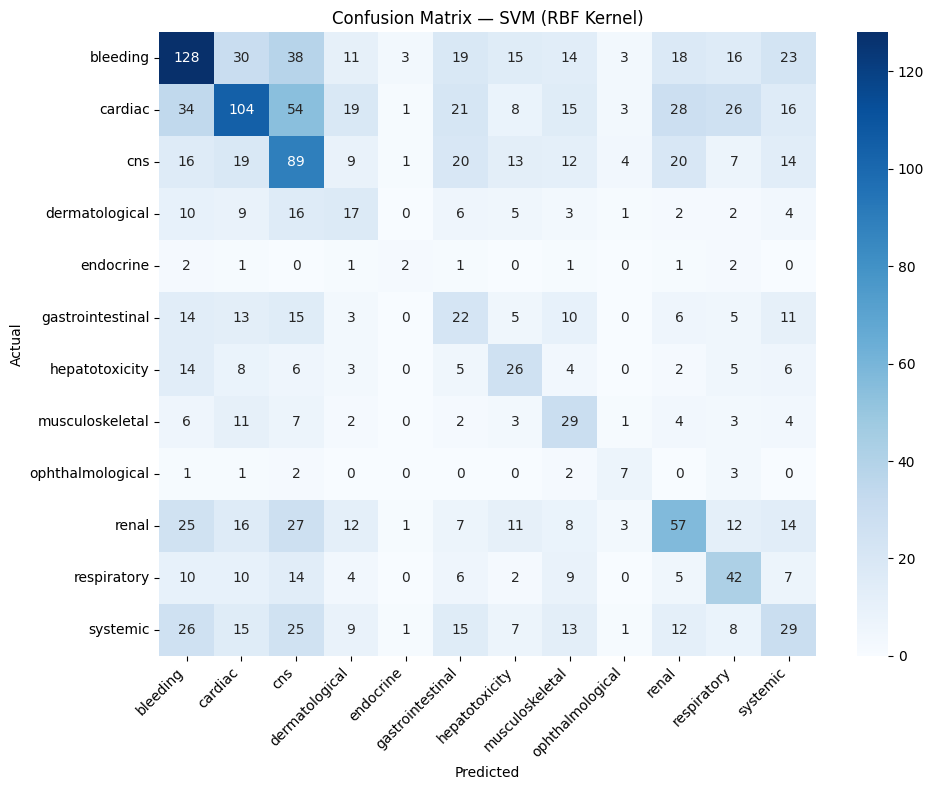

In [8]:
print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_,
    zero_division=0
))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True, fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — SVM (RBF Kernel)')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Step 8 — 5-Fold Cross-Validation

Running 5-fold cross-validation...
CV F1 scores (5 folds): [0.241  0.2366 0.2597 0.2486 0.273 ]
Mean ± Std:             0.2518 ± 0.0132


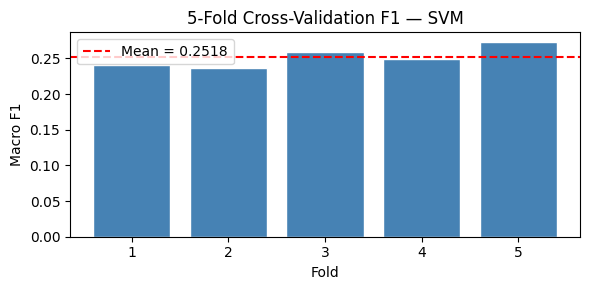

In [9]:
print('Running 5-fold cross-validation...')
cv_scores = cross_val_score(
    pipeline,
    X_train, y_train,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
print(f'CV F1 scores (5 folds): {cv_scores.round(4)}')
print(f'Mean ± Std:             {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='white')
ax.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.4f}')
ax.set_title('5-Fold Cross-Validation F1 — SVM')
ax.set_xlabel('Fold')
ax.set_ylabel('Macro F1')
ax.legend()
plt.tight_layout()
plt.show()

## Step 9 — Summary

In [10]:
summary = pd.DataFrame([{
    'Model':         'SVM (RBF kernel, pivot)',
    'Drug pairs':    f'{X.shape[0]:,}',
    'Features':      X.shape[1],
    'Accuracy':      round(acc, 4),
    'F1 (macro)':    round(f1_macro, 4),
    'F1 (weighted)': round(f1_weighted, 4),
    'CV F1 Mean':    round(cv_scores.mean(), 4),
    'CV F1 Std':     round(cv_scores.std(), 4),
}])
display(summary)
summary.to_csv('data/svm_results.csv', index=False)
print('Results saved to data/svm_results.csv')
print(f'\nGNN target: F1 > 0.75  (SVM baseline = {f1_macro:.4f})')

,Model,Drug pairs,Features,Accuracy,F1 (macro),F1 (weighted),CV F1 Mean,CV F1 Std
0,"SVM (RBF kernel, pivot)","8,452",1548,0.3264,0.2977,0.3284,0.2518,0.0132


Results saved to data/svm_results.csv

GNN target: F1 > 0.75  (SVM baseline = 0.2977)
